<a href="https://colab.research.google.com/github/dan-the-man7/lab-3/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


In [ ]:
## x and y variables created and used to plot sin wave graph

x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0,0.1,size=x.shape)

plt.scatter(x, y, s=10)
plt.title("Noisy sine data")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

## Initiasing w and b
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1

## Finding gradient descent

learning_rate = 0.05
losses = []

for step in range(200):

  # Calculates the model's current prediction
  y_h = w * x + b

  # Calculates the current loss
  loss = np.mean((y_h - y) ** 2)

  # Calculates gradients (derivatives of w and b)

  dw = np.mean(2 * (y_h - y) * x)
  db = np.mean(2 * (y_h - y))

  # This is the update rule. It moves w and b a small step opposite the gradient
  w -= learning_rate * dw
  b -= learning_rate * db


  # Stores the loss value in the losses array, to use later for plotting a loss graph

  losses.append(loss)

  print(f"Final value for w ={w:.3f}, b= {b:.3f}, loss = {losses[-1]:.4f}")

  fig, axes = plt.subplots(1,2, figsize=(12,4))

  # Plots loss curve to flatten out
  axes[0].plot(losses)
  axes[0].set_title("Loss over training steps")
  axes[0].set_xlabel("step")
  axes[0].set_ylabel("MSE loss")


  axes[1].scatter(x,y, s=10, label="data")
  axes[1].plot(x, w * x + b, color="red", label="fitted line")
  axes[1].set_title("Fit: single neuron vs. sine data")
  axes[1].legend()

  plt.tight_layout()
  plt.show()





## Student Reasoning for Part 1.1
2. The model is overfitting, this is because it is too simple to capture the true structure, therefore the training loss rises to a high value and stays high despite the training time.

A single neuron never fits a sine wave because, the function y_hat = w*x + b is the graph of a straight line, and will never fit a sine wave, no matter how long you train. This is because a sine wave, never bevomes becomes a line at any point except locally or instantaneously.



## Student Reflection 1.2

1. Without tanh, h = z1 = x @ W1 + b1. Because W1W2 and W2 + b2 are fixed numbers, they are of the form y_hat = wx + b, no matter how many hidden neurons are used. Stacking layers without a non-linearity between them, is mathematically identical to one linear layer.

2. Each hidden neuron applies tanh to its own linear transformation of x, so each one produces its own S-shaped curved, which is shifted and scaled differently. The output layer takes a weighted combination of these 8 bent curves.

3. Backward propagation refers to the process of working backward from the loss through each layer of the network, to compute how every parameter contributed to the final error value.

## Student Reflection 1.3

1. The blue line represents a slow stable learning. This means that the model slowly descends towards the minimum loss, but it takes about 1000 steps to reach a loss of 10^0.

  The orange line represents efficient learning rate. This means that it takes a relatively lesser time to reach 10^0. It does it about 10 times faster than the blue line.

  The green line represents an exploding gradient, this means that on the first step, the error increases rapidly and goes off the chart.

2. A high learning rate means that the step taken towards the bottom of the gradient. Instead of taking little steps, a massive step is taken causing it to go completely across the valley and land on the opposite wall.

/tmp/ipykernel_1310/165586089.py:25: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_h - y_col) ** 2)
/tmp/ipykernel_1310/165586089.py:32: RuntimeWarning: overflow encountered in matmul
  dh = d_yh @ W2.T
/tmp/ipykernel_1310/165586089.py:33: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


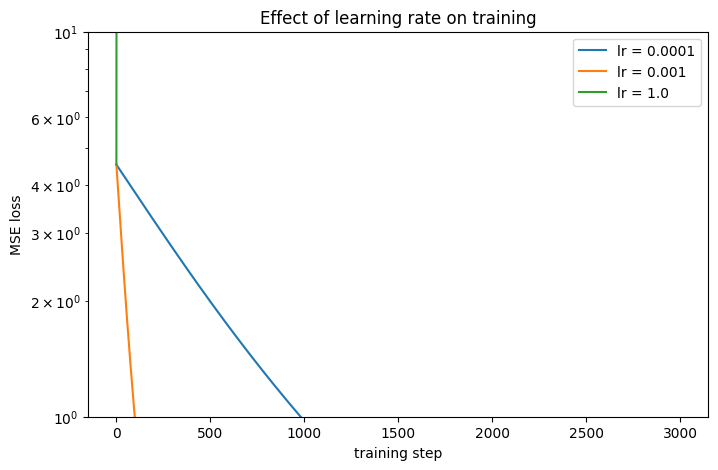

In [ ]:

#Part 1.3
def train_toy(learning_rate, steps = 3000):
# Resets the seed every time the function is called
# guaranteeing that all three runs begin from the exact same random initial weights.
# Therefore, any differences seen afterwards are caused by only the learning rate.
    np.random.seed(RANDOM_STATE)

    W1 = np.random.randn(1,8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8,1) * 0.5
    b2 = np.random.randn(1) * 0.5

    x_col = x.reshape(-1, 1)
    y_col = y.reshape(-1, 1)

    losses = []

    for step in range(steps):
      # Forward pass
      z1 = x_col @ W1 + b1
      # Applies tanh
      h = np.tanh(z1)
      y_h = h @ W2 + b2

      ## Mean Squared Error
      loss = np.mean((y_h - y_col) ** 2)

      # Backward Pass

      d_yh = 2 * (y_h - y_col) / len(y_col)
      dW2 = h.T @ d_yh
      dB2 = d_yh.sum(axis = 0)
      dh = d_yh @ W2.T
      dz1 = dh * (1 - np.tanh(z1) ** 2)
      dW1 = x_col.T @ dz1
      db1 = dz1.sum(axis=0)

      # Update, adjust every parameter a small step opposite its gradient.
      W1 -= learning_rate * dW1
      b1 -= learning_rate * db1
      W2 -= learning_rate * dW2
      b2 -= learning_rate * dB2

      losses.append(loss)

    return losses

# print(f"Final Loss Value is {losses[-1]:.4f}")

learning_rates = [0.0001, 0.001, 1.0]
results = {}

for lr in learning_rates:
  results[lr] = train_toy(lr, steps=3000)

fig, ax = plt.subplots(figsize=(8, 5))

for lr, losses in results.items():
  ax.plot(losses, label=f"lr = {lr}")

ax.set_yscale("log")
ax.set_xlabel("training step")
ax.set_ylabel("MSE loss")
ax.set_title("Effect of learning rate on training")
ax.legend()
plt.show()


Shape: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Missing Values:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Class Distribution:
NObeyesdad
Obesity_Type_I         16.627191
Obesity_Type_III       15.348176
Obesity_Type_II        14.069162
Overweight_Level_I     13.737565
Overweight_Level_II    13.737565
Normal_Weight          13.595452
Insufficient_Weight    12.884889
Name: proportion, dtype: float64


/tmp/ipykernel_1310/2497892919.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=obesity, x='NObeyesdad', palette='viridis')


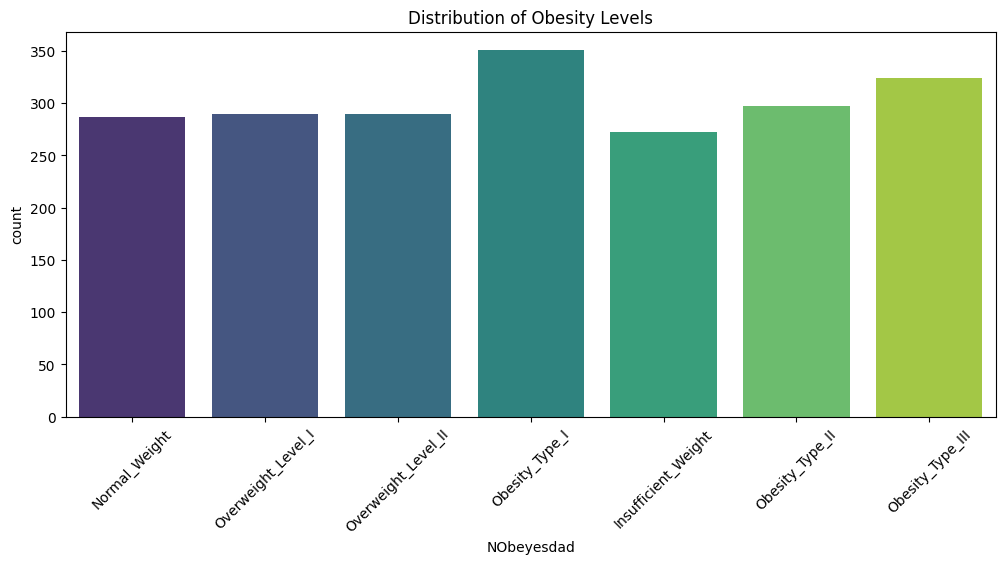


DataLoaders created
Batches in train_loader: 40


In [ ]:

OBESITY_URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv'
obesity = pd.read_csv(OBESITY_URL)


print(f"Shape: {obesity.shape}")
display(obesity.head())
obesity.info()
display(obesity.describe())
print("\nMissing Values:")
print(obesity.isnull().sum())


print("\nClass Distribution:")
print(obesity['NObeyesdad'].value_counts(normalize=True)*100)

plt.figure(figsize=(12, 5))
sns.countplot(data=obesity, x='NObeyesdad', palette='viridis')
plt.title('Distribution of Obesity Levels')
plt.xticks(rotation=45)
plt.show()


obesity['BMI'] = obesity['Weight'] / (obesity['Height']**2)

#Encoded Categorical Columns Updated for Neural Networks

binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})
obesity['Gender'] = obesity['Gender'].map({'Female': 0, 'Male': 1})


freq_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity['CAEC'] = obesity['CAEC'].map(freq_map)
obesity['CALC'] = obesity['CALC'].map(freq_map)

encoded_df = pd.get_dummies(obesity, columns=['MTRANS'], drop_first=True)


le = LabelEncoder()
encoded_df['NObeyesdad'] = le.fit_transform(encoded_df['NObeyesdad'])

# Stratified 60/20/20 split
X = encoded_df.drop(columns=['NObeyesdad'])
y = encoded_df['NObeyesdad']

# Splits off 20% for test, leaving 80% in temp
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
# Splits the 80% temp into 60% train and 20% validation (0.25 * 0.80 = 0.20)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)

# Scales numeric features (Fit on TRAIN only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train.values, dtype=torch.long)
y_val_t = torch.tensor(y_val.values, dtype=torch.long)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Batches in train_loader: {len(train_loader)}")

## Student Revision 2.1

1. Passing a one-hot encoded vector, would require a dot product between the network's predicted probabilities and this vector for calculating the loss. Because a one-hot vector is mostly zeros, this forces the computer to do a number of redundant multiplications by zero.

2. Because Random Forests are tree-based models, they learn by finding the optimal threshold splits. Therefore, the absolute scale of the number does not matter to a decision tree; only the the relative ordering of the values matters. However, neural networds learn using the gradient descent, and gradients are heavily influenced by the scale of the inputs. If one feature is measured in thousands, like daily calories and another is measured in single digits (like height in meters), the gradient updates for the large feature will be larger that the small one. Therefore, this imbalance causes the model's loss to go off by a great distance, or explode, rather than smoothly descending to the minimum.

3. Setting shuffle=True randomly scrambles the order of the training dataset. By shuffling the data, you ensure that every batch contains a diverse, representative mixture of different classes. This produces a much more accurate and stable gradient.

In [29]:
class FeedForward(nn.Module):
  def __init__(self, input_dim, hidden_sizes=(64,32), n_classes=7):
    super(FeedForward, self).__init__()

    # First Hidden Layer
    self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
    self.relu1 = nn.ReLU()

    # Second Hidden Layer
    self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
    self.relu2 = nn.ReLU()

    self.out = nn.Linear(hidden_sizes[1], n_classes)

  def forward(self, x):

    out = self.fc1(x)
    out = self.relu1(out)

    out = self.fc2(out)
    out = self.relu2(out)

    out = self.out(out)
    return out

# Automatically selects GPU, otherwise CPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_train_scaled.shape[1]

# model is instantiated and moved to the device
model = FeedForward(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7).to(DEVICE)

print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params}")


FeedForward(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (out): Linear(in_features=32, out_features=7, bias=True)
)

Total Trainable Parameters: 3655


## Section 2.2

1. Layer 1 (fc1: input_dim to 64): Weights = input_dim×64, Biases = 64. Total = (input_dim×64)+64.

  Layer 2 (fc2: 64 to 32): Weights = 64×32, Biases = 32. Total = (64×32)+32=2,080.

  Output Layer (out: 32 to 7): Weights = 32×7, Biases = 7. Total = (32×7)+7=231.

  Summing all these up will match the number

2. ReLu avoids the vanishing gradient problem. This is because, ReLu's derivation is a constant 1 for any positive input, therefore allowing gradients to flow smoothly through deep networks without shrinking.

3. If the ReLu functions (non-linear activation functions) are removed, combining multiple linear layers (like fc1, fc2, out) collapse mathematically into a single linear operation.

In [ ]:
# Part 2.3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Plain SGD uses one learning rate for every parameter in the network, applied uniformly.
# Adam instead keeps a running estimate of each parameter's own gradient history and adapts its effective step size per-parameter
# some weights get bigger effective steps, some smaller, based on how consistent their gradients have been.


n_epochs = 50

history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

for epoch in range(n_epochs):

    # Training
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        # This clears out old gradients before computing new ones

        logits = model(xb.to(DEVICE))

        loss = criterion(logits, yb.to(DEVICE))

        loss.backward()
        # Backward Pass

        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb.to(DEVICE)).sum().item()
        total += xb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for xb, yb in val_loader:
            logits = model(xb.to(DEVICE))
            loss = criterion(logits, yb.to(DEVICE))

            val_running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == yb.to(DEVICE)).sum().item()
            val_total += xb.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    # Report
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:2d}/{n_epochs} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

best_val_acc = max(history["val_acc"])
best_epoch = history["val_acc"].index(best_val_acc)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss over epochs")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_title("Accuracy over epochs")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()



Running: tiny (8,)
Running: default (64, 32)
Running: large (256, 128, 64)


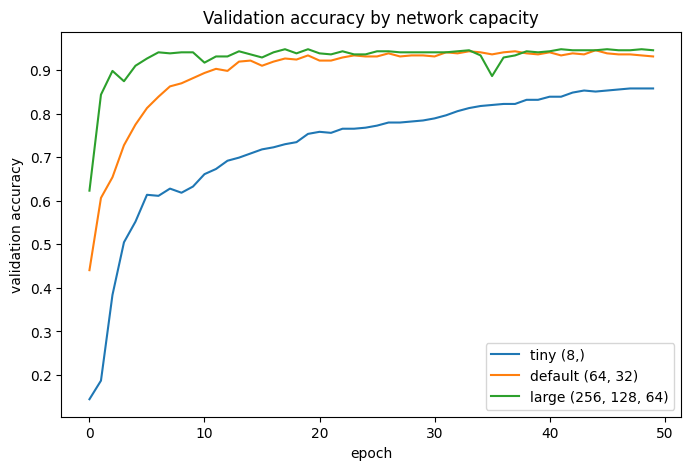

Running: lr=0.0001
Running: lr=0.001
Running: lr=0.1


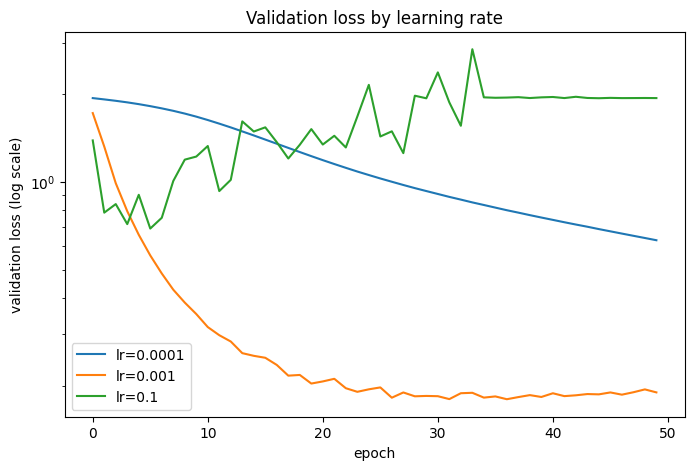

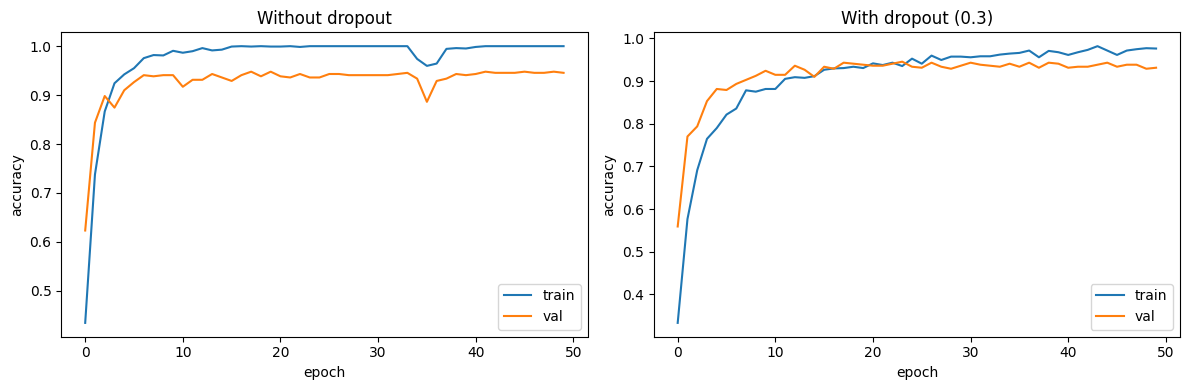

In [37]:
# Part 2.3

def build_model(input_dim, num_classes, hidden_sizes=(64, 32), dropout=0.0):
    layers = []
    in_features = input_dim
    for h in hidden_sizes:
        layers.append(nn.Linear(in_features, h))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        in_features = h
    layers.append(nn.Linear(in_features, num_classes))
    return nn.Sequential(*layers).to(DEVICE)

num_classes = len(le.classes_)

def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32,
                    epochs=50, dropout=0.0):
    torch.manual_seed(RANDOM_STATE)
    model = build_model(input_dim, num_classes, hidden_sizes=hidden_sizes, dropout=dropout)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_loader_local = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader_local = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for xb, yb in train_loader_local:
            optimizer.zero_grad()
            logits = model(xb.to(DEVICE))
            loss = criterion(logits, yb.to(DEVICE))
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb.to(DEVICE)).sum().item()
            total += xb.size(0)

        history["train_loss"].append(running_loss / total)
        history["train_acc"].append(correct / total)

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader_local:
                logits = model(xb.to(DEVICE))
                loss = criterion(logits, yb.to(DEVICE))
                val_running_loss += loss.item() * xb.size(0)
                val_correct += (logits.argmax(dim=1) == yb.to(DEVICE)).sum().item()
                val_total += xb.size(0)

        history["val_loss"].append(val_running_loss / val_total)
        history["val_acc"].append(val_correct / val_total)

    return history

# Experiment A

capacity_configs = {
    "tiny (8,)": (8,),
    "default (64, 32)": (64, 32),
    "large (256, 128, 64)": (256, 128, 64),
}

capacity_results = {}
for name, sizes in capacity_configs.items():
    print(f"Running: {name}")
    capacity_results[name] = run_experiment(hidden_sizes=sizes)

fig, ax = plt.subplots(figsize=(8, 5))
for name, hist in capacity_results.items():
    ax.plot(hist["val_acc"], label=name)
ax.set_title("Validation accuracy by network capacity")
ax.set_xlabel("epoch")
ax.set_ylabel("validation accuracy")
ax.legend()
plt.show()

# Experiment B

lr_configs = [1e-4, 1e-3, 1e-1]
lr_results = {}

for lr in lr_configs:
    print(f"Running: lr={lr}")
    lr_results[lr] = run_experiment(lr=lr)

fig, ax = plt.subplots(figsize=(8, 5))
for lr, hist in lr_results.items():
    ax.plot(hist["val_loss"], label=f"lr={lr}")
ax.set_yscale("log")
ax.set_title("Validation loss by learning rate")
ax.set_xlabel("epoch")
ax.set_ylabel("validation loss (log scale)")
ax.legend()
plt.show()

# Experiment C
no_dropout_hist = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0)
dropout_hist = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(no_dropout_hist["train_acc"], label="train")
axes[0].plot(no_dropout_hist["val_acc"], label="val")
axes[0].set_title("Without dropout")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("accuracy")
axes[0].legend()

axes[1].plot(dropout_hist["train_acc"], label="train")
axes[1].plot(dropout_hist["val_acc"], label="val")
axes[1].set_title("With dropout (0.3)")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Student Reflection 2.3

1. Forward Pass: logits = model(xb) replaces the manual matrix multiplication.

Computes Gradients: loss.backward() replaces the manual backpropagation formulas by utilizing PyTorch's autograd engine.

Update Rule: optimizer.step() replaces the manual weight adjustment step (W1 -= learning_rate * dW1).

2. The three learning rates reproduce the same three regimes.
lr=0.0001 underfits from being too slow lr=0.001 converges smoothly to the lowest loss, and lr=0.1 is unstable and oscillates around a much higher loss, confirming that a large learning rate causes overshooting regardless of the problem.

3. By default, PyTorch accumulates gradients on subsequent backward passes rather than replacing them.

Without calling optimizer.zero_grad(), the new gradients calculated for the current batch will be added to the old gradients left over from the previous batch. This causes gradient corruption, erratic updates, and breaks training optimization.